In [1]:
import os
os.chdir("/nfshome/narjis")

In [9]:
import h5py
import numpy as np
h5_path = "Downloads/brightfield_particles.hdf5"
with h5py.File(h5_path, "r") as h5_file:
    data = np.copy(h5_file["data"]).astype(np.float32)
    labels = np.copy(h5_file["labels"])

In [10]:
import torch
def contrast_from_middle_rows(images: torch.Tensor) -> torch.Tensor:
    """
    Compute standard deviation (RMS contrast) from the 4 middle rows of each image in a batch.
    
    Args:
        images: Tensor of shape (B, C, H, W)
    
    Returns:
        Tensor of shape (B,) with contrast values.
    """
    B, C, H, W = images.shape
    mid = H // 2
    rows = images[:, :, mid - 2:mid + 2, :]  # (B, C, 4, W)

    gray = rows[:,0,:,:]  # Convert to grayscale: (B, 4, W)
    contrast = gray.std(dim=(1, 2))  # Compute std over height and width

    return contrast  # shape: (B,)

In [14]:
images_0.shape

(32462, 16, 201)

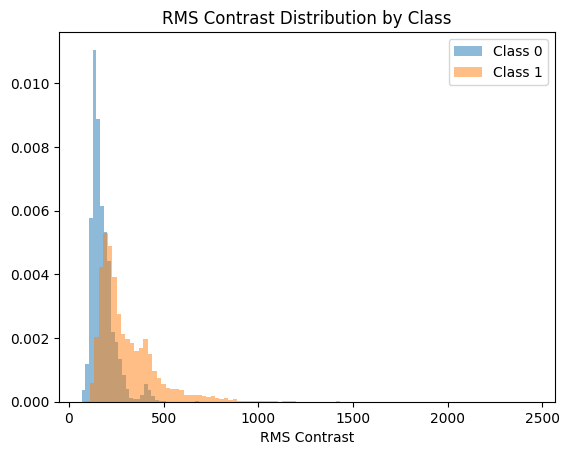

In [20]:
images_0 = data[labels == 0]  # Ensure shape is (B, C, H, W)
images_1 = data[labels == 1]  # Ensure shape is (B, C, H, W)
images_0 = torch.tensor(images_0, dtype=torch.float32).unsqueeze(1)
images_1 = torch.tensor(images_1, dtype=torch.float32).unsqueeze(1)
contrast_0 = contrast_from_middle_rows(images_0)
contrast_1 = contrast_from_middle_rows(images_1)
import matplotlib.pyplot as plt
plt.hist(contrast_0.numpy(), bins=100, alpha=0.5, label='Class 0',density=True)
plt.hist(contrast_1.numpy(), bins=100, alpha=0.5, label='Class 1',density=True)
plt.xlabel('RMS Contrast')
plt.title('RMS Contrast Distribution by Class')
plt.legend()
plt.savefig("rms_contrast_distribution.png")
plt.show()